# Performing Exploaratory Data Analysis on Extracted Data (EDA)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

In [4]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

df = pd.read_csv("../data/interim/labeled_reviews.csv")

In [5]:
display(df.head())

,index_id,clothing_id,age,review_text,rating,return_category
0,0,767,33,Absolutely wonderful - silky and sexy and comf...,4,Other
1,1,1080,34,Love this dress! it's sooo pretty. i happene...,5,Other
2,2,1077,60,I had such high hopes for this dress and reall...,3,Defect
3,3,1049,50,"I love, love, love this jumpsuit. it's fun, fl...",5,Other
4,4,847,47,This shirt is very flattering to all due to th...,5,Other


In [6]:
df["word_count"] = df["review_text"].apply(lambda x: len(str(x).split()))

In [7]:
display(df.head())

,index_id,clothing_id,age,review_text,rating,return_category,word_count
0,0,767,33,Absolutely wonderful - silky and sexy and comf...,4,Other,8
1,1,1080,34,Love this dress! it's sooo pretty. i happene...,5,Other,62
2,2,1077,60,I had such high hopes for this dress and reall...,3,Defect,98
3,3,1049,50,"I love, love, love this jumpsuit. it's fun, fl...",5,Other,22
4,4,847,47,This shirt is very flattering to all due to th...,5,Other,36


### Step 1: The "Angry Rant" Hypothesis (Length vs. Category)

**Business Intuition:** Customers are more emotional/verbose when a product fails (Defect) compared to when it just doesn't fit (Sizing).

**Formal Hypothesis:** 

*   $H_0$ (Null): The review length for "Defect" is equal to the mean review length for "Sizing".
*   $H_1$ (Alternative): The lengths are different.
*   **Significance Level ($\alpha$):** 0.05
  
Before testing, we will need to test for normality and homogeneity of variances using Shapiro-Wilk and QQ plots.


In [8]:
"""Shapiro-Wilk Test for Normality"""
from scipy.stats import shapiro
alpha: float = 0.05

# Due to large sample size, we will take a random sample of 1000 for the Shapiro-Wilk test
sample_data = df["word_count"].sample(1000, random_state=42)

"""
H_0 = Data is Normal
H_1: Data is not Normal

alpha = 5%
"""

stat, p_value = shapiro(sample_data)
print(f"Shapiro P-Value: {p_value}")
if p_value < alpha:
    print("Result: NOT Normal. (Do NOT use T-Test)")
else:
    print("Result: Normal. (Safe for T-Test)")

Shapiro P-Value: 1.0511674137872286e-17
Result: NOT Normal. (Do NOT use T-Test)


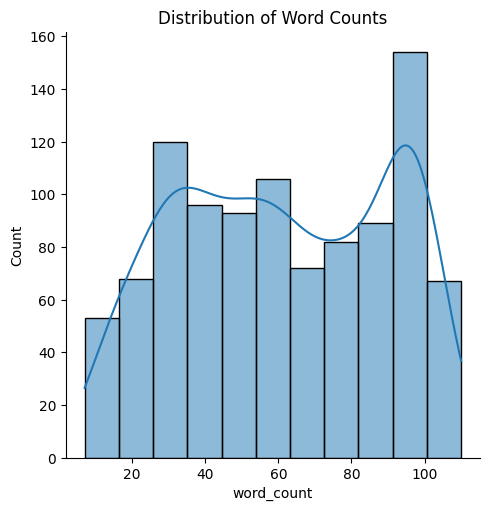

In [9]:
"""QQ Plot"""

# Plotting the distribution of word counts
sns.displot(x="word_count", data=df.sample(1000), kde=True, fill=True)
plt.title("Distribution of Word Counts")
plt.show()

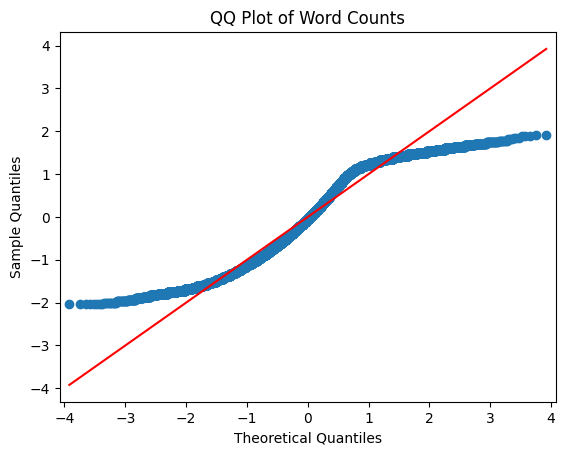

In [10]:
from statsmodels.graphics.gofplots import qqplot
from scipy.stats.distributions import norm

qqplot(df["word_count"], line="s", dist=norm, fit=True) # fit=True, to enable Python learn μ and σ from data
plt.title("QQ Plot of Word Counts")
plt.show()

Since the word count distribution is not normal, we will used the non-parametric Mann-Whitney U test to compare the two categories.

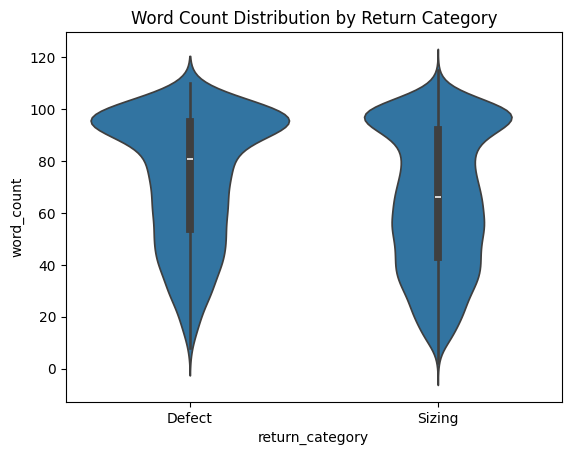

In [11]:
from scipy.stats import mannwhitneyu

defects = df.loc[df["return_category"] == "Defect"]["word_count"]
sizing = df.loc[df["return_category"] == "Sizing"]["word_count"]

returns_cat = df[df["return_category"].isin(["Defect", "Sizing"])]

sns.violinplot(x="return_category", y="word_count", data=returns_cat)

plt.title("Word Count Distribution by Return Category")
plt.show()

In [12]:
u_stat, p_value = mannwhitneyu(defects, sizing, alternative="two-sided")

print(f"Mann Whitney U test p-value: {p_value}")
if p_value < alpha:
    print("Rejecting the Null Hypothesis. Significant difference between the two categories.")
else:
    print("Failing to Reject the Null Hypthesis. No Significant difference between the two categories.")

Mann Whitney U test p-value: 1.0617578031425583e-40
Rejecting the Null Hypothesis. Significant difference between the two categories.


Since there is a **signficant difference** in review lengths between the two categories, we can conclude that the **Angry Rant** hypothesis holds true. Customers tend to write longer reviews when reporting defects compared to sizing issues. This insight can be valuable for understanding customer behavior and tailoring responses accordingly. `word_count` then becomes a feature for our model later!

### Step 2: The **Star Rating** Correlation

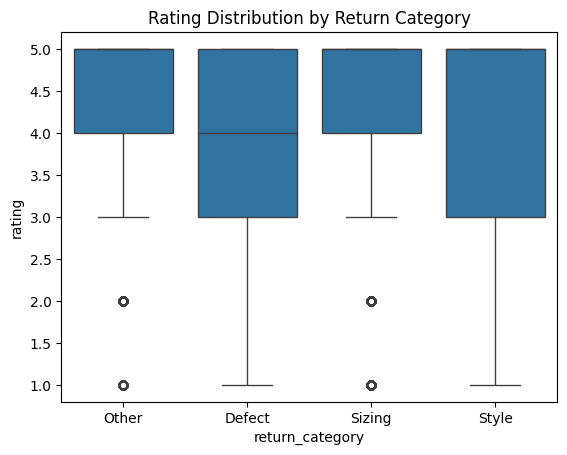


If Rating = 5, it could be anything.
If Rating = 1 or 2, it is highly likely to be a Defect.
This tells us that rating is a weak but valid discriminator.



In [13]:
sns.boxplot(x="return_category", y="rating", data=df)
plt.title("Rating Distribution by Return Category")
plt.show()

print("""
If Rating = 5, it could be anything.
If Rating = 1 or 2, it is highly likely to be a Defect.
This tells us that rating is a weak but valid discriminator.
""")


### Step 3: Text-Nuance (N-Grams)    

Comparing the most common n-grams (bigrams and trigrams) between the two categories can reveal distinct language patterns used by customers when describing defects versus sizing issues.

In [14]:
df.columns

Index(['index_id', 'clothing_id', 'age', 'review_text', 'rating',
       'return_category', 'word_count'],
      dtype='object')

Visualizing Bigrams for Category: Other


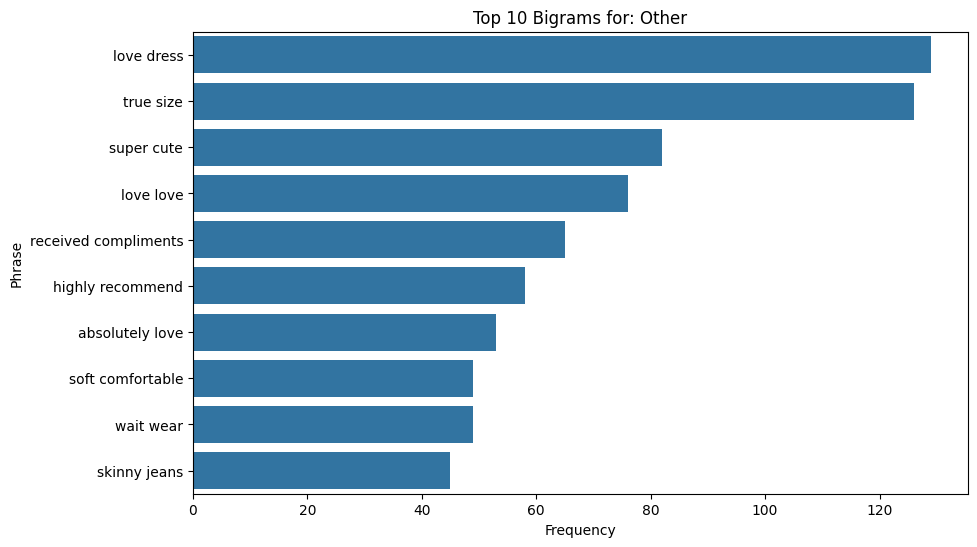

Visualizing Bigrams for Category: Defect


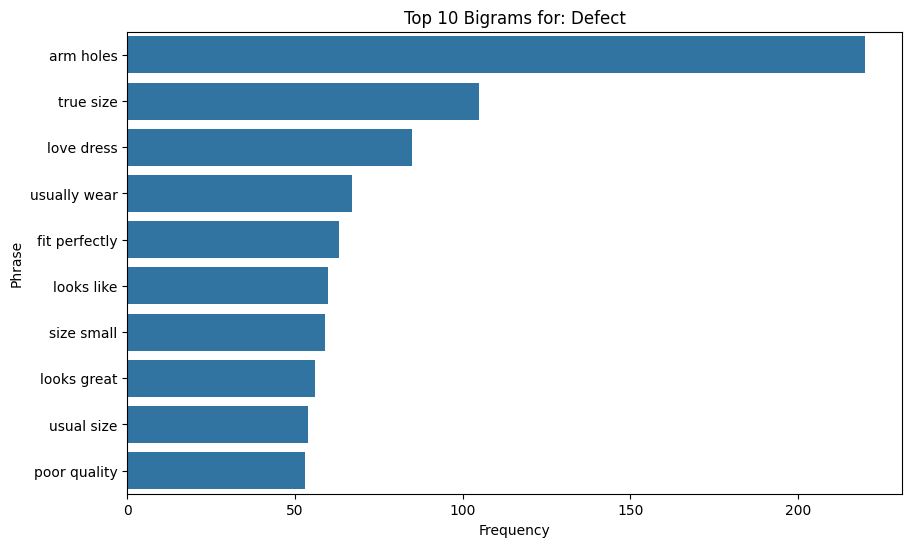

Visualizing Bigrams for Category: Sizing


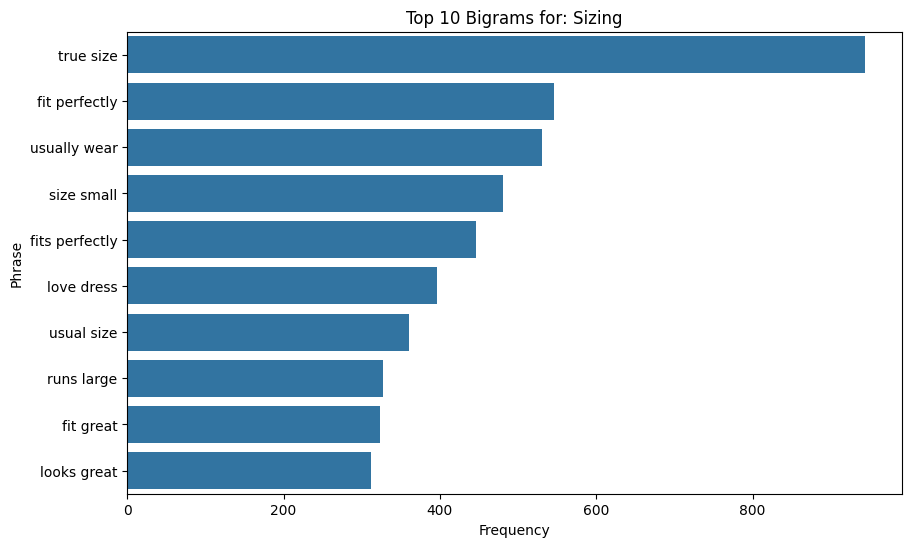

Visualizing Bigrams for Category: Style


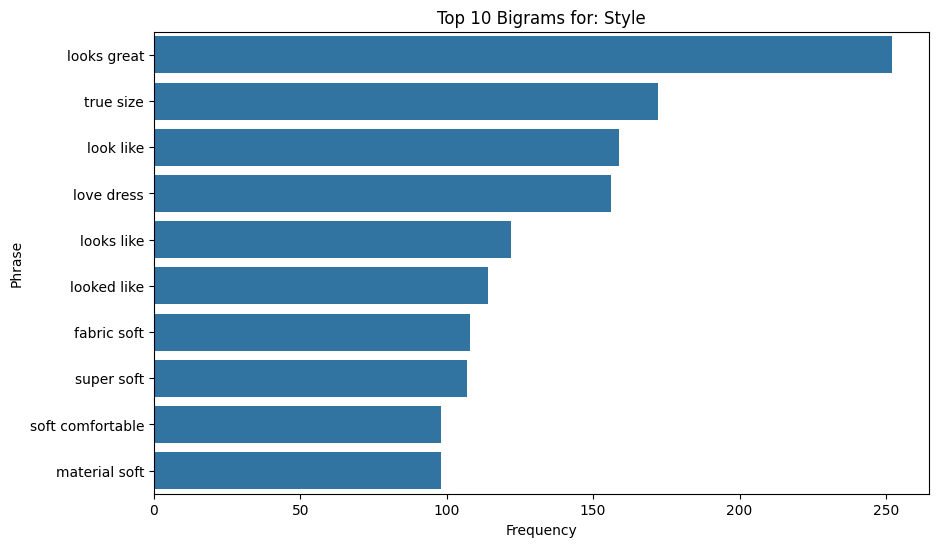

In [25]:
from sklearn.feature_extraction.text import CountVectorizer
from scipy import sparse
from src.utils import visualize_ngrams



# EXECUTION
# Looping through categories to compare them side-by-side
categories = df["return_category"].unique()
# categories = ["Defect", "Sizing"]

for cat in categories:
    print(f"Visualizing Bigrams for Category: {cat}")
    visualize_ngrams(df, category_name=cat, ngram_range=(2, 2))

    # print(f"Visualizing Trigrams for Category: {cat}")
    # visualize_ngrams(df, category_name=cat, ngram_range=(3, 3), top_k=10)

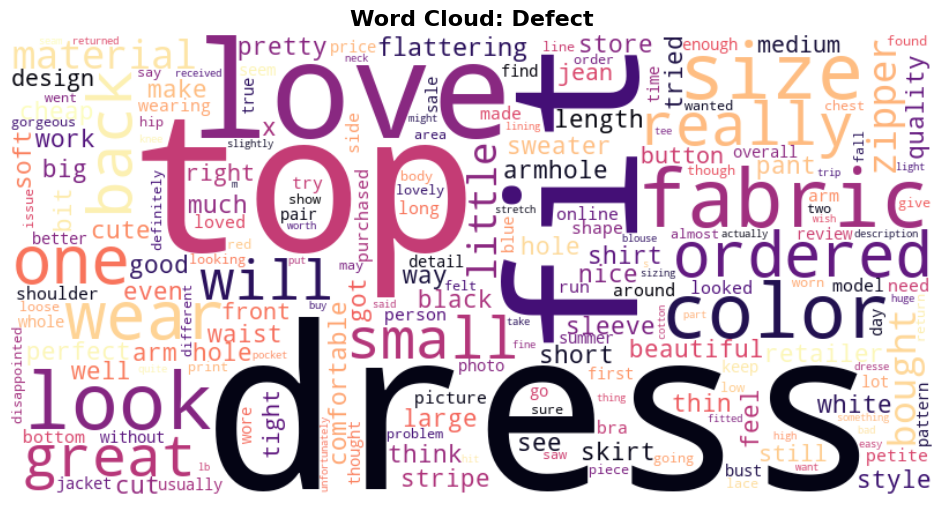

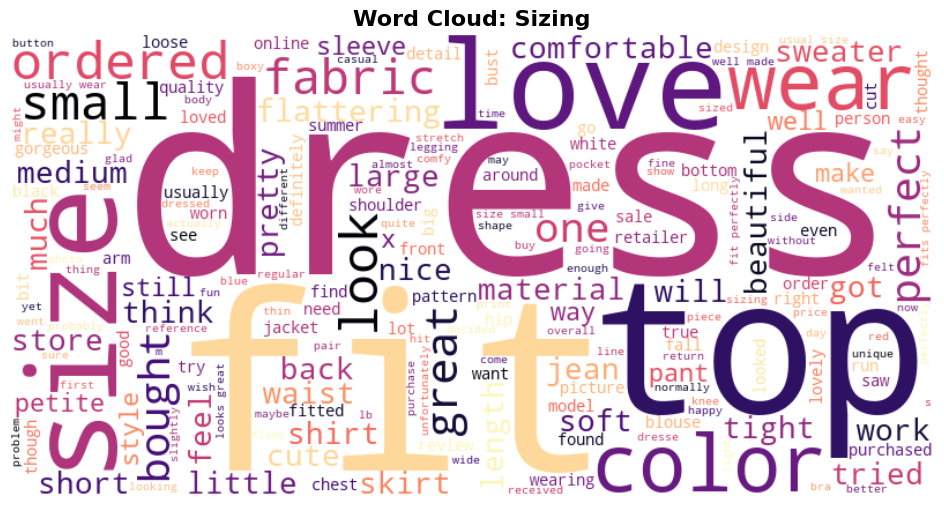

In [24]:
from wordcloud import WordCloud
from src.utils import plot_wordcloud


# Executing for "Defect" and "Sizing"
plot_wordcloud(df, "Defect")
plot_wordcloud(df, "Sizing")
    

### Data Poisoning 

**The classes are heavily overlapping.** `True Size` and `Fit Perfectly` are higly appearing across categories. These labels do not provide much information to the model about the return reason. 

- **Why? Customers leave mixed reviews:** "I love the dress, it fits true to size, but the arm hole ripped."
- **The Model Risk:** If we train on this raw text, the model will see "true size" and have **NO IDEA** if it's `Defect`, `Sizing`, or `Style`. It will guess randomly.

#### Solution: Custom Stop Word Removal (Domain Specific)

We must remove these generic positive phrases from the training data so the model focuses on the differences (e.g., "arm holes" vs "runs large").

1. **Filter out generic phrases:** That do not contribute to distinguishing between return reasons. `e.g.` ["true size", "love dress", "fit perfectly", "looks like", "looks great"].
**NB:** These are good for sentiment analysis, but bad for Root Cause analysis. We don't care if they love it; we care why they returned it.

2. **The Negative Strategy:** Focus on phrases that indicate problems or issues, such as "ripped", "too tight", "color faded", etc. These phrases are more likely to be associated with specific return reasons. 
**NB:** We need to keep phrases like "NOT true to size". `Standard stop-word removal deletes "not"`. We must be careful.